In [ ]:
# --- path bootstrap: make `src` importable and repo-relative paths resolve ---
# This notebook lives in experiments/notebooks/; run this cell first.
import os, sys
from pathlib import Path

PROJECT_ROOT = Path("/root/Hessian-Approximation-for-Toy-Models")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)  # restore repo root as cwd for relative data/figure paths


# Edge of Stability — exact Hessian vs. its approximations

We take the **small MLP** from `runs.db` (`mlp_08580ee2573a`: `64 → [16]×8 → 10`, `tanh`,
cross-entropy, trained on `digits`, 2 976 parameters) and retrain it **from scratch with
full-batch gradient descent** at a *constant* learning rate `η`.

At a schedule of steps we measure the **top eigenvalue** (sharpness) of:

* the **exact loss Hessian** `∇²L`, and
* every **Hessian approximation** in the repo (GNH, FIM, KFAC, EKFAC, … — configurable).

**What to look for**

* *Edge of Stability* (Cohen et al. 2021): under full-batch GD the sharpness `λ_max(∇²L)`
  rises until it reaches `2/η`, then **hovers there** (the loss decreases non-monotonically).
  We draw the `2/η` line for reference.
* For the approximations the question is whether their top eigenvalue **tracks** the exact one
  (and so also plateaus), or saturates at a different level. GNH/FIM are full PSD curvature
  proxies; KFAC/EKFAC are block-diagonal (per-layer) so their global top eigenvalue is
  typically *lower* than the exact Hessian's.

**How (this model is small enough for dense eigendecomposition).** With only 2 976 parameters
the dense Hessian is a `2976×2976` (~34 MB) matrix. Building it in one shot as
`jax.hessian(mean_loss)` (~0.2 s on GPU) and calling `jnp.linalg.eigvalsh` (~0.25 s) is both
**exact** and ~10–40× faster than power iteration on per-sample HVPs — and it hands us the
*entire* spectrum for free, so we can also watch the most-negative eigenvalue and the number
of negative curvature directions. (Power iteration / Lanczos only wins once `n` is large
enough that an `O(n²)` matrix and `O(n³)` eigendecomposition stop being cheap.) Each
approximation is materialized via its `estimate_hessian()` and eigendecomposed the same way.


In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
# Force CPU by uncommenting; GPU is strongly preferred (dense Hessian build is a vectorized
# forward-over-reverse pass that the GPU eats for breakfast).
# os.environ.setdefault("JAX_PLATFORMS", "cpu")

import logging

# Silence the collector's INFO spam. Set the level on the `src` logger itself (not just the
# root) so it sticks even if something upstream already called logging.basicConfig(INFO).
logging.getLogger("src").setLevel(logging.WARNING)

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from jax.flatten_util import ravel_pytree
from tqdm.auto import tqdm

from src.config import (
    ModelConfig,
    LossType,
    PseudoTargetGenerationStrategy,
    HessianApproximationMethod as HAM,
)
from src.utils.models.registry import ModelRegistry
from src.utils.data.data import load_split_from_disk, normalize_for_loss, DatasetEnum
from src.utils.loss import get_loss
from src.utils.train import initialize_model
from src.hessians.utils.data import ModelContext
from src.hessians.collector import CollectorActivationsGradients
from src.hessians.computer.registry import HessianComputerRegistry

print("jax devices:", jax.devices())

INFO:2026-06-16 19:48:57,739:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


INFO:2026-06-16 19:48:57,%f:xla_bridge.py:backends:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
jax devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3), CudaDevice(id=4), CudaDevice(id=5), CudaDevice(id=6), CudaDevice(id=7)]


## Configuration

`LR` is the full-batch GD step size; the EoS threshold is `2 / LR`. You want `LR` *small
enough* that the initial sharpness sits **below** `2/LR` — so you can watch it climb up to the
edge — but large enough that it gets there within `STEPS`. `0.05`–`0.2` works well for this
model on `digits` (`LR=0.1` → threshold `20`, and the sharpness starts around a few). Push
`LR` toward `1`+ and the sharpness is already at/above the edge from initialization.


In [2]:
# ---- training ----
LR = 0.03  # constant full-batch GD learning rate; EoS threshold = 2/LR
STEPS = 1000  # number of full-batch GD steps
MEASURE_EVERY = 25  # eigendecompose every this many steps
INIT_SEED = 0  # parameter init seed

# ---- which curvature matrices to track ----
# 'exact' is always included. Add/remove approximations freely. Available:
#   gnh, fim, kfac, ekfac, mac, emac, shampoo, eshampoo, identity, eidentity,
#   block_fim, block_hessian
APPROXIMATORS = [
    HAM.GNH,
    HAM.FIM,
    HAM.KFAC,
    HAM.EKFAC,
    HAM.MAC,
    HAM.EMAC,
    HAM.SHAMPOO,
    HAM.ESHAMPOO,
]

# ---- collector: how pseudo-targets are drawn for the Fisher / K-factored methods ----
# MCMC             : sample MCMC_SAMPLES label draws from the model's softmax per example
#                    (k = MCMC_SAMPLES). k=1 processes N samples — ~10x cheaper than ALL_CLASSES.
# ALL_CLASSES      : deterministic; every class weighted by softmax (k = num_classes = 10).
# EMPIRICAL_FISHER : single pass with the ground-truth labels (k = 1).
PT_STRATEGY = PseudoTargetGenerationStrategy.MCMC
MCMC_SAMPLES = 1  # k for MCMC (1 is cheapest; raise to average out sampling noise)
ANALYSIS_SEED = 42  # rng seed for MCMC pseudo-target sampling

## Model + data

Architecture and dataset are copied verbatim from the saved `mlp_08580ee2573a/model.json`.
We reuse the **cached train split** the original model was trained on.

In [3]:
SMALL_MLP = {
    "architecture": "mlp",
    "input_dim": 64,
    "hidden_dim": [16] * 8,
    "output_dim": 10,
    "activation": "tanh",
    "loss": "cross_entropy",
}
model_config = ModelConfig.from_dict(SMALL_MLP)
model = ModelRegistry.get_model(model_config, seed=INIT_SEED)
loss_fn = get_loss(LossType.CROSS_ENTROPY)
print("layers:", model.get_layer_names())
print("num_params:", model.num_params)

SPLIT_DIR = Path("experiments/datasets/digits/splits/default")
train_ds, test_ds = load_split_from_disk(DatasetEnum.DIGITS, SPLIT_DIR)
train_ds, test_ds = normalize_for_loss(train_ds, test_ds, LossType.CROSS_ENTROPY)
print(f"N_train={len(train_ds)}  N_test={len(test_ds)}  input={train_ds.inputs.shape}")

params0 = initialize_model(model, model.input_dim, key=jax.random.PRNGKey(INIT_SEED))
flat0, unravel = ravel_pytree(params0)
N_PARAMS = flat0.size
print("flattened params:", N_PARAMS)

layers: ['linear_0', 'linear_1', 'linear_2', 'linear_3', 'linear_4', 'linear_5', 'linear_6', 'linear_7', 'output']
num_params: 2976
N_train=3823  N_test=1797  input=(3823, 64)
flattened params: 2976


## Curvature spectra (dense + `eigvalsh`)

* **Exact Hessian.** `dense_hessian(flat)` builds the full Hessian of the *mean* full-batch
  loss in one jitted `jax.hessian` call — exactly the objective GD minimizes. We then take the
  full eigenvalue spectrum. (Note: we build it directly here rather than via the repo's
  `HessianComputer.build()`, which materializes a per-sample Hessian in a `scan` over all
  3 823 examples — that's the slow path; the mean-loss Hessian is one vectorized pass.)
* **Approximations.** Each estimator's `estimate_hessian()` returns its dense
  `(n_params, n_params)` matrix; we eigendecompose that.

In [4]:
@jax.jit
def dense_hessian(flat):
    """Exact Hessian of the mean full-batch loss, (n_params, n_params)."""

    def mean_loss(p):
        return loss_fn(model.apply(unravel(p), train_ds.inputs), train_ds.targets)

    H = jax.hessian(mean_loss)(flat)
    return 0.5 * (H + H.T)  # symmetrize away float round-off


def spectrum(H):
    """Ascending eigenvalues of a symmetric matrix."""
    return jnp.linalg.eigvalsh(H)


def exact_spectrum(flat):
    return np.asarray(spectrum(dense_hessian(flat)))

## Measure every curvature matrix at the current parameters

One collector run feeds all the Fisher / K-factored approximations per measurement. Two
subtleties to be aware of when reading the logs:

* **MCMC vs ALL_CLASSES cost.** MCMC draws `MCMC_SAMPLES` pseudo-labels per example
  (`k = MCMC_SAMPLES`), so `k=1` pushes only `N` samples through the collector — roughly
  **10× cheaper** than `ALL_CLASSES` (`k = 10` classes).
* **Eigenvalue-corrected methods under MCMC.** EKFAC/EMAC/ESHAMPOO/EIDENTITY fit their
  eigenvalue correction on a *second, independent* collector run (a different rng key), so the
  correction isn't overfit to the same samples that set the eigenvectors. With MCMC + any such
  method you'll therefore see **two** `[COLLECTION]` blocks per measurement — that's intended,
  not a double-count. Deterministic strategies (`ALL_CLASSES` / `EMPIRICAL_FISHER`) have no
  sampling noise, so they reuse the single run.

For the exact Hessian we keep the **full spectrum** (sharpness `λ_max`, most-negative `λ_min`,
and the number of negative directions).

In [5]:
# Methods whose eigenvalue correction wants an independent corr-context under MCMC.
_CORRECTED = {HAM.EKFAC, HAM.ESHAMPOO, HAM.EMAC, HAM.EIDENTITY}
_IS_MCMC = PT_STRATEGY == PseudoTargetGenerationStrategy.MCMC
_NEEDS_CORR = _IS_MCMC and any(m in _CORRECTED for m in APPROXIMATORS)


def top_eigval(H):
    """Largest eigenvalue of a dense symmetric matrix."""
    return float(np.linalg.eigvalsh(np.asarray(H))[-1])


def collect(params, rng_key):
    """One collector run at the current params. `rng_key` is only used by MCMC; the
    deterministic strategies ignore it."""
    reps = MCMC_SAMPLES if _IS_MCMC else model.output_dim
    collector = CollectorActivationsGradients(
        model=model,
        params=params,
        loss_fn=loss_fn,
        pseudo_target_strategy=PT_STRATEGY,
        pseudo_target_repetitions=reps,
    )
    return collector.collect(
        dataset=train_ds, rng_key=rng_key
    )  # in-memory (no save dir)


def measure(params):
    """Return (tops, exact_spec): tops maps label -> lambda_max, exact_spec is the
    full eigenvalue array of the exact Hessian."""
    flat, _ = ravel_pytree(params)
    model_ctx = ModelContext.create(
        model=model, params=params, dataset=train_ds, loss_fn=loss_fn
    )
    tops = {}

    exact_spec = exact_spectrum(flat)
    tops["exact"] = float(exact_spec[-1])

    if APPROXIMATORS:
        data = collect(params, jax.random.PRNGKey(ANALYSIS_SEED))
        # Independent sample for the eigenvalue correction only when it matters
        # (MCMC + a corrected method); otherwise reuse the single run.
        corr = (
            collect(params, jax.random.PRNGKey(ANALYSIS_SEED + 1))
            if _NEEDS_CORR
            else data
        )
        for method in APPROXIMATORS:
            cc = HessianComputerRegistry.get_compute_context(method, data, model_ctx)
            comp = HessianComputerRegistry.get_computer(method, cc, corr_context=corr)
            comp.build(base_directory=None)
            tops[method.value] = top_eigval(comp.estimate_hessian())
    return tops, exact_spec

## Full-batch gradient descent

A single jitted step computes the full-batch gradient and applies a constant-LR SGD update.

In [6]:
tx = optax.sgd(LR)


@jax.jit
def gd_step(params, opt_state):
    def L(p):
        return loss_fn(model.apply(p, train_ds.inputs), train_ds.targets)

    loss, grads = jax.value_and_grad(L)(params)
    updates, opt_state = tx.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    gnorm = optax.tree.norm(grads)
    return params, opt_state, loss, gnorm


params = params0
opt_state = tx.init(params)

labels = ["exact"] + [m.value for m in APPROXIMATORS]
history = {
    "step": [],
    "loss": [],
    "grad_norm": [],
    "tops": [],
    "exact_min": [],
    "exact_nneg": [],
}

t0 = time.time()
pbar = tqdm(range(STEPS + 1))
last_loss = float("nan")
for step in pbar:
    if step % MEASURE_EVERY == 0:
        tops, exact_spec = measure(params)
        history["step"].append(step)
        history["loss"].append(last_loss)
        history["tops"].append(tops)
        history["exact_min"].append(float(exact_spec[0]))
        history["exact_nneg"].append(int((exact_spec < 0).sum()))
        pbar.set_postfix(
            loss=f"{last_loss:.3f}", sharp=f"{tops['exact']:.2f}", thr=f"{2 / LR:.2f}"
        )
    if step == STEPS:
        break
    params, opt_state, loss, gnorm = gd_step(params, opt_state)
    last_loss = float(loss)
    history["grad_norm"].append(float(gnorm))
print(f"done in {time.time() - t0:.1f}s")

  0%|          | 0/1001 [00:00<?, ?it/s]

done in 634.3s


## Edge of Stability — exact Hessian sharpness

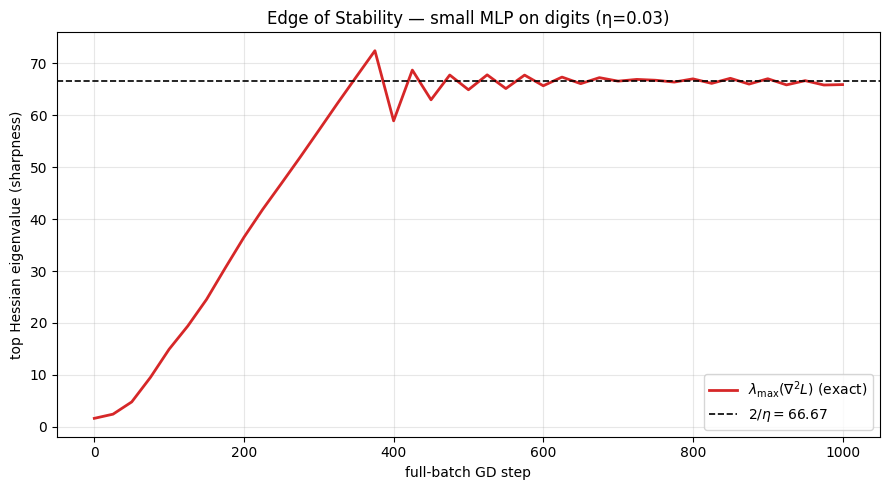

In [7]:
steps = np.array(history["step"])
sharp_exact = np.array([t["exact"] for t in history["tops"]])
thr = 2.0 / LR

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    steps, sharp_exact, color="C3", lw=2, label=r"$\lambda_{\max}(\nabla^2 L)$ (exact)"
)
ax.axhline(thr, color="k", ls="--", lw=1.2, label=rf"$2/\eta = {thr:.2f}$")
ax.set_xlabel("full-batch GD step")
ax.set_ylabel("top Hessian eigenvalue (sharpness)")
ax.set_title(f"Edge of Stability — small MLP on digits (η={LR})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Exact Hessian vs. approximations

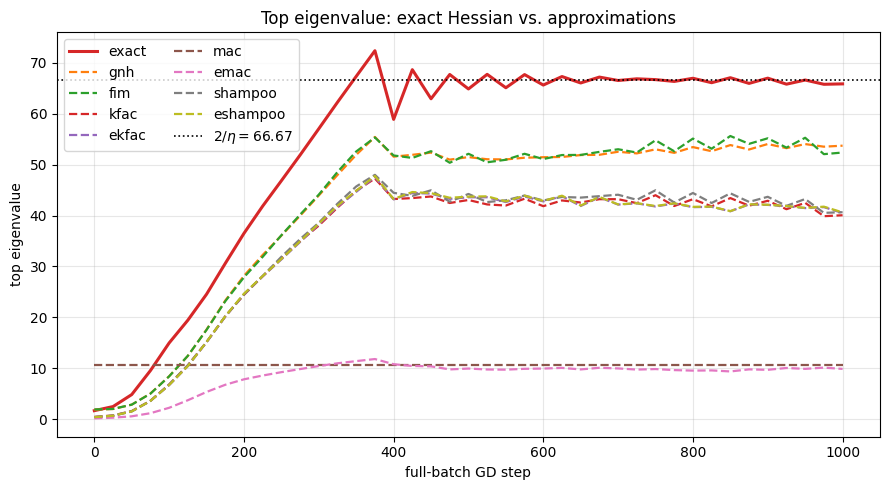

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"exact": "C3"}
for i, lab in enumerate(labels):
    y = np.array([t[lab] for t in history["tops"]])
    style = dict(lw=2.2) if lab == "exact" else dict(lw=1.6, ls="--")
    ax.plot(steps, y, label=lab, color=colors.get(lab, f"C{i}"), **style)
ax.axhline(thr, color="k", ls=":", lw=1.2, label=rf"$2/\eta = {thr:.2f}$")
ax.set_xlabel("full-batch GD step")
ax.set_ylabel("top eigenvalue")
ax.set_title("Top eigenvalue: exact Hessian vs. approximations")
ax.legend(ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Loss, and the negative-curvature side of the spectrum

The loss decreasing **non-monotonically** once the sharpness pins to `2/η` is the behavioural
signature of EoS. Because we have the full spectrum, we also plot the most-negative eigenvalue
and the count of negative directions — these shrink as GD settles into a near-convex basin.

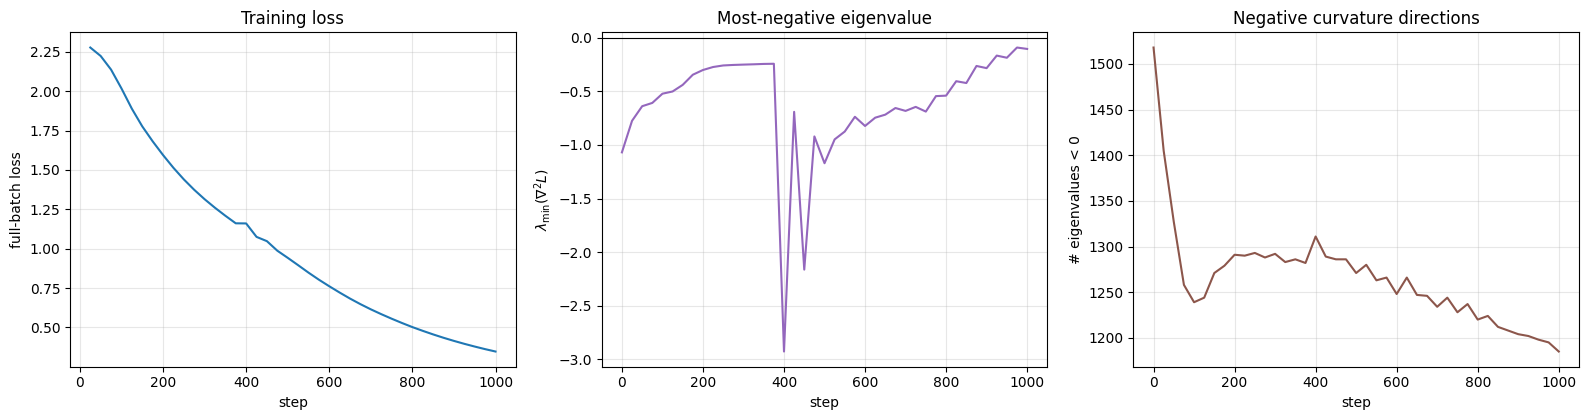

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
loss_curve = np.array(history["loss"])
m = ~np.isnan(loss_curve)
axes[0].plot(steps[m], loss_curve[m], color="C0")
axes[0].set_xlabel("step")
axes[0].set_ylabel("full-batch loss")
axes[0].set_title("Training loss")
axes[0].grid(alpha=0.3)

axes[1].plot(steps, np.array(history["exact_min"]), color="C4")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("step")
axes[1].set_ylabel(r"$\lambda_{\min}(\nabla^2 L)$")
axes[1].set_title("Most-negative eigenvalue")
axes[1].grid(alpha=0.3)

axes[2].plot(steps, np.array(history["exact_nneg"]), color="C5")
axes[2].set_xlabel("step")
axes[2].set_ylabel("# eigenvalues < 0")
axes[2].set_title("Negative curvature directions")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tracking ratio: how well does each approximation follow the exact sharpness?

`λ_max(approx) / λ_max(exact)` over training. A flat line near a constant means the
approximation tracks the *shape* of the sharpness trajectory (and its own EoS-like plateau),
even if it sits at a different absolute level.

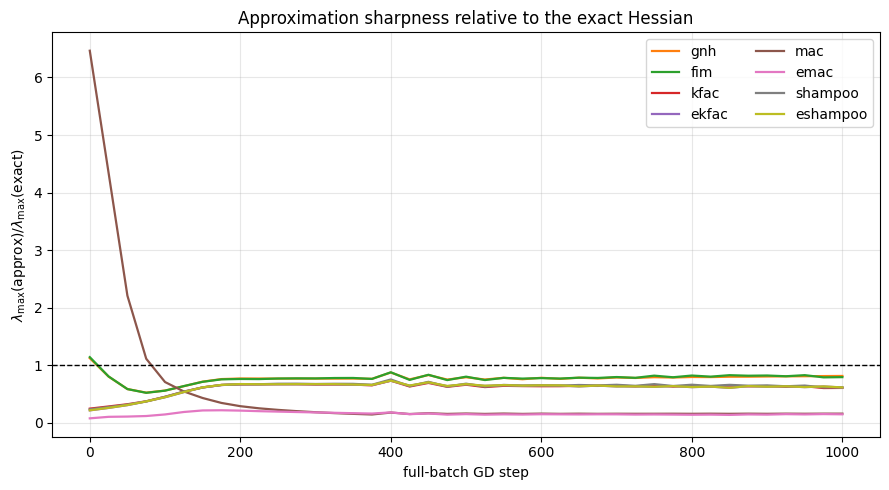

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, lab in enumerate(labels):
    if lab == "exact":
        continue
    y = np.array([t[lab] for t in history["tops"]])
    ax.plot(steps, y / sharp_exact, label=lab, color=f"C{i}", lw=1.6)
ax.axhline(1.0, color="k", ls="--", lw=1)
ax.set_xlabel("full-batch GD step")
ax.set_ylabel(r"$\lambda_{\max}(\mathrm{approx}) / \lambda_{\max}(\mathrm{exact})$")
ax.set_title("Approximation sharpness relative to the exact Hessian")
ax.legend(ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Notes & knobs

* **Reaching the edge.** If `λ_max(exact)` never reaches `2/η`, increase `LR` or `STEPS`.
  If the loss explodes, lower `LR`. The plateau is clearest when the run spends a few hundred
  steps at the edge.
* **Cost.** With dense `eigvalsh` the exact Hessian is cheap (~0.4 s/measurement on GPU); the
  per-measurement collector + `estimate_hessian()` build of the approximations now dominates.
  Trim `APPROXIMATORS` or raise `MEASURE_EVERY` to speed things up. (For a *much* larger model
  you'd switch the exact Hessian to a matrix-free Lanczos/power-iteration on `estimate_hvp` —
  not worth it at 3 k params.)
* **More approximations.** Add `HAM.MAC`, `HAM.SHAMPOO`, `HAM.ESHAMPOO`, `HAM.EMAC`,
  `HAM.IDENTITY`, … to `APPROXIMATORS`. Block-diagonal methods (KFAC/EKFAC) report the top
  eigenvalue of the *full* block-diagonal matrix, i.e. the max over per-layer blocks.
* **Full spectrum.** `exact_spectrum(flat)` returns every eigenvalue, so you can also plot the
  spectral density / bulk at any checkpoint, not just the extremes.
* **MSE variant.** To reproduce the canonical Cohen et al. setup, switch `loss` to `"mse"`
  in `SMALL_MLP`, use one-hot targets, and re-run — EoS shows up the same way.
